In [103]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading & Data Parsing

In [78]:
df = pd.read_csv("../data/ethiopia.csv")

```Column	    Unit	Description

YEAR	    -	    Year of observation
DOY	        -	    Day of year (1–365 / 366). Must be  converted to a proper date during cleaning

T2M	        °C	    Mean daily air temperature at 2 meters above the surface

T2M_MAX	    °C	    Maximum daily temperature at 2 meters
T2M_MIN	    °C	    Minimum daily temperature at 2 meters
T2M_RANGE   °C	    Daily temperature range (T2M_MAX − T2M_MIN)

PRECTOTCORR	mm/day	Bias-corrected total daily precipitation

RH2M	    %	    humidity at 2 meters
WS2M	    m/s	    Mean daily wind speed at 2 meters
WS2M_MAX	m/s	    Maximum daily wind speed at 2 meters

PS	        kPa	    Atmospheric surface pressure
QV2M	    g/kg	Specific humidity - mass of water vapor per unit mass of moist air

In [7]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [79]:
df["Country"] = ["ETHIOPIA" for _ in range(len(df))]

In [16]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATETIME
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,ETHIOPIA,2026-03-27
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,ETHIOPIA,2026-03-28
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,ETHIOPIA,2026-03-29
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,ETHIOPIA,2026-03-30
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,ETHIOPIA,2026-03-31


In [80]:
df["DATETIME"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [15]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATETIME
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ETHIOPIA,2015-01-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ETHIOPIA,2015-01-02
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ETHIOPIA,2015-01-03
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ETHIOPIA,2015-01-04
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ETHIOPIA,2015-01-05


In [81]:
df["MONTH"] = df["DATETIME"].dt.month

In [19]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATETIME,MONTH
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,ETHIOPIA,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,ETHIOPIA,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,ETHIOPIA,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,ETHIOPIA,2026-03-30,3
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,ETHIOPIA,2026-03-31,3


#### Summary Statistics & Missing-Value Report

In [82]:
df.eq(-999).sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATETIME       0
MONTH          0
dtype: int64

`we don't have -999(null) value in our data. So we don't need to replace it with np.nan`

In [84]:
df.duplicated().sum()

np.int64(0)

`We don't have duplicated row, so no need to drop any`

In [85]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATETIME,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


* The data is expected to have less outlier coz the median(50%) of all columns is close to the value of the mean. 
* The lesser std tells that the data is less noisy. 
* On total daily precipitation "PRECTOTCORR" the 75th percentile(75%) is much lesser that the Max value of the column, which might be the indication of an outlier there. 

In [38]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATETIME       0
MONTH          0
dtype: int64

#### Outlier Detection & Basic Cleaning

In [86]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [87]:
z_df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,MONTH
0,-1.579631,-1.685342,-2.286045,-0.163269,-2.603645,1.658923,-0.577866,-1.806604,1.088524,1.330345,0.929615,-2.412067,-1.560009
1,-1.579631,-1.675933,-1.985701,0.294724,-2.354311,1.818576,-0.577866,-2.383500,0.595061,0.547137,1.030146,-2.687237,-1.560009
2,-1.579631,-1.666524,-1.885586,0.352882,-2.400342,1.891860,-0.577866,-2.346850,-0.304782,-0.725576,0.728554,-2.653370,-1.560009
3,-1.579631,-1.657115,-1.047782,0.211122,-1.276418,1.022926,-0.577866,-2.006821,-1.611007,-2.042790,0.326431,-2.158064,-1.560009
4,-1.579631,-1.647706,-1.058320,-0.017874,-1.115310,0.748113,-0.577866,-1.448251,-0.928867,-1.277382,-0.276753,-1.743192,-1.560009


In [88]:
(abs(z_df["YEAR"]) > 3).sum()

np.int64(0)

In [89]:
for col in z_df.columns:
    outliers = (abs(z_df[col]) > 3).sum()
    print(f"{col}: {outliers} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
T2M_RANGE: 0 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers
PS: 34 outliers
QV2M: 11 outliers
MONTH: 0 outliers


##### The N vs Outlier ratio

*could we be okay with the outlier?*

In [90]:
N = len(df)

In [91]:
# if outlier ratio is less than 0.001, we can be okay 
# since that doesn't affect the data distribution much

for col in z_df.columns:
    outliers = (abs(z_df[col]) > 3).sum()
    outlier_ratio = outliers / N
    print(col, " ------------", outlier_ratio > 0.001)

# so if the column has True consider outliners management

YEAR  ------------ False
DOY  ------------ False
T2M  ------------ False
T2M_MAX  ------------ False
T2M_MIN  ------------ True
T2M_RANGE  ------------ False
PRECTOTCORR  ------------ True
RH2M  ------------ True
WS2M  ------------ False
WS2M_MAX  ------------ True
PS  ------------ True
QV2M  ------------ True
MONTH  ------------ False


In [92]:
# T2M_MIN - Minimum daily temperature at 2 meters
col = "T2M_MIN"
# maximum value
_min = df[col].min()  # 2.713, which is normal minimum temperature record in Ethiopia, so we can keep it as is
# since min record ever known is -7.5 degrees Celsius, ref [https://www.nationmaster.com/country-info/profiles/Ethiopia/Weather]
print(_min)


1.17


In [93]:
# using IQR-based clipping
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df[col] = df[col].clip(lower_bound, upper_bound)

For PRECTOTCORR we have normal maximum of 250mm [ecoflow](ecoflow.com). On our data we have maximum of 95 mm, which suggests the outline is not due to incorrect measurement. The difference between the mean and the max is simply due to high-variance so we can Cap it.

In [94]:
# PRECTOTCORR - Bias-corrected total daily precipitation

# using IQR-based clipping
col = "PRECTOTCORR"

q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df[col] = df[col].clip(lower_bound, upper_bound)

In [95]:
# RH2M -- humidity at 2 meters
col = "RH2M"
_min, _max = df[col].min(), df[col].max()
print(_min, _max)

14.42 91.93


The lowest and highest humidity(%) to be recorded in Ethiopis is <10% and >95% respectively. [source](https://www.worlddata.info/africa/ethiopia/climate-adis-abeba.php#:~:text=The%20highest%20value%20of%2080%25%20is%20experienced%20here%20in%20August.)

This indicates the min and max we're having are quite valid and we can go with capping methods to manage outlier

In [96]:
# using IQR-based clipping
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df[col] = df[col].clip(lower_bound, upper_bound)

In [97]:
# WS2M_MAX  -- Maximum daily wind speed at 2 meters
# using IQR-based clipping
col = "WS2M_MAX"
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df[col] = df[col].clip(lower_bound, upper_bound)

In [98]:
# PS -- Atmospheric surface pressure
_min, _max = df["PS"].min(), df["PS"].max()
print(_min, _max)

76.36 77.37


[Note] the little difference between the min and max might due to the measure is in kPa. 

But these measures are quite in the normal range

In [99]:
# IQR-based clipping
col = "PS"
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df[col] = df[col].clip(lower_bound, upper_bound)

In [100]:
# QV2M -- Specific humidity - mass of water vapor per unit mass of moist air
# IQR-based clipping
col = "QV2M"
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1   
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df[col] = df[col].clip(lower_bound, upper_bound)

##### Exporting the cleaned DataFrame

In [102]:
df.to_csv("../data/ethiopia_cleaned.csv", index=False)

#### Time Series Analysis

In [104]:
df["DATETIME"].dtype

dtype('<M8[us]')

In [105]:
plot_df = df.sort_values("DATETIME")

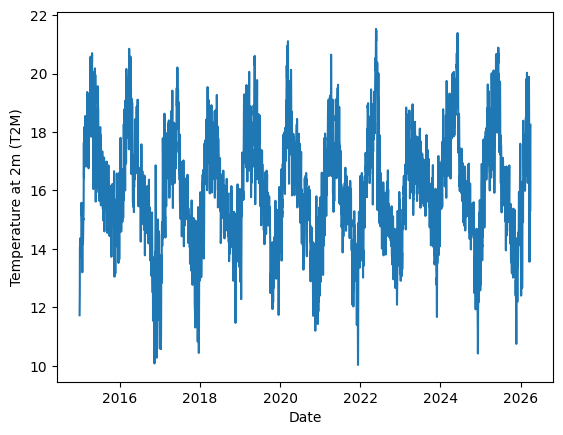

In [109]:
plt.plot(plot_df["DATETIME"], plot_df["T2M"])
plt.xlabel("Date")
plt.ylabel("Temperature at 2m (T2M)");

Text(0, 0.5, 'Temperature at 2m (T2M)')

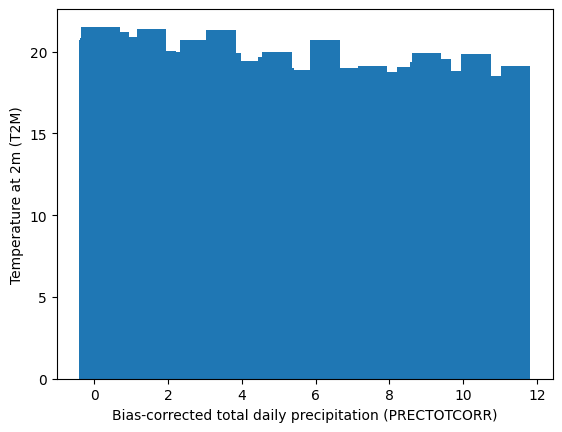

In [110]:
plt.bar(plot_df["PRECTOTCORR"], plot_df["T2M"])
plt.xlabel("Bias-corrected total daily precipitation (PRECTOTCORR)")
plt.ylabel("Temperature at 2m (T2M)");

`The data seems quite uniform.`

#### Correlation & Relationship Analysis

<Axes: >

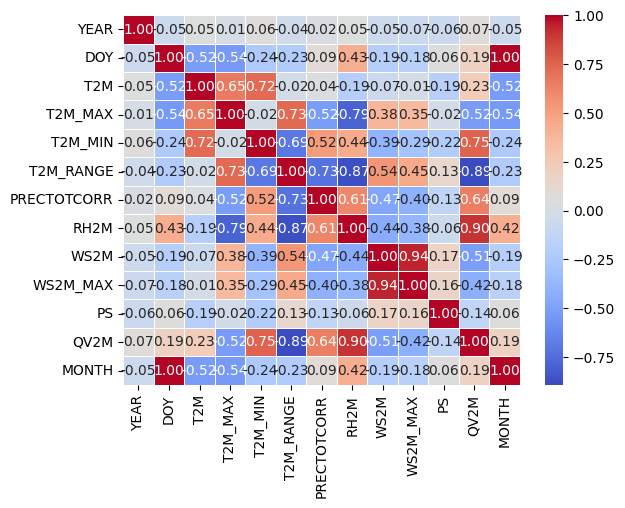

In [112]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

# heatmap of correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

The three strongest correlation being;
* DOY and MONTH -- this seems trivia though
* RH2M & QV2M = 0.90
* T2M_RANGE & QV2M = 0.89
* T2M_RANGE & RH2M = 0.87

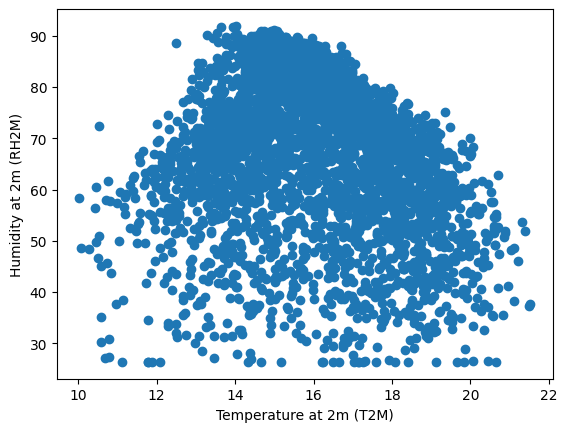

In [113]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature at 2m (T2M)")
plt.ylabel("Humidity at 2m (RH2M)");

`It seems these two, Temperature at 2m and Humidity at 2m have reverse relationship`

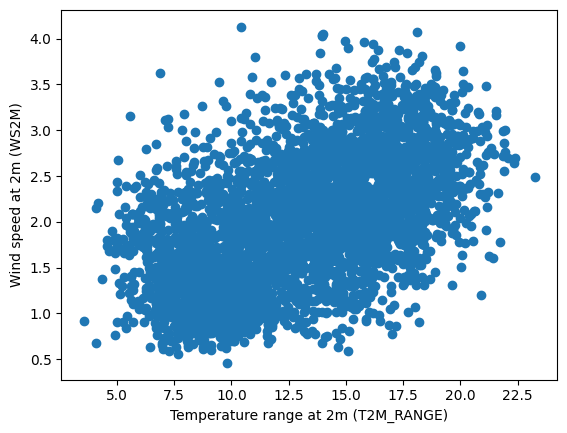

In [116]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature range at 2m (T2M_RANGE)")
plt.ylabel("Wind speed at 2m (WS2M)");  

`It seems Temperature range at 2m and wind speet at 2m have direct relationship`

#### Distribution Analysis

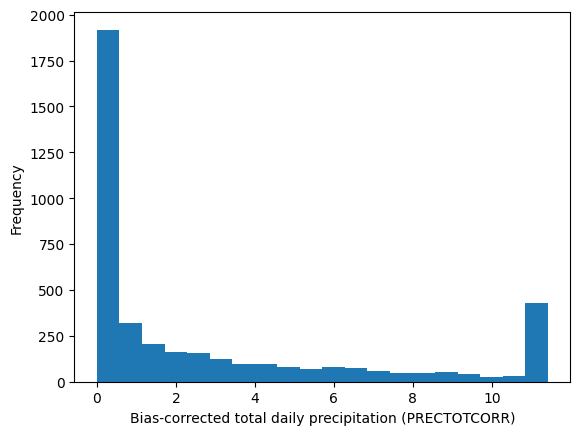

In [118]:
plt.hist(df["PRECTOTCORR"], bins=20)
plt.xlabel("Bias-corrected total daily precipitation (PRECTOTCORR)")
plt.ylabel("Frequency");

`well this is highly skewed`

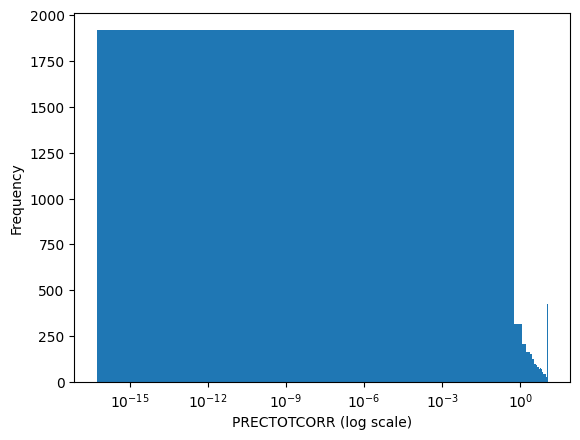

In [119]:
plt.hist(df["PRECTOTCORR"], bins=20)
plt.xscale("log")
plt.xlabel("PRECTOTCORR (log scale)")
plt.ylabel("Frequency");

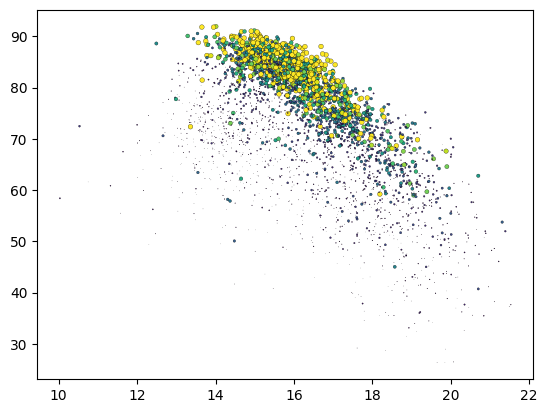

In [121]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"],
    c=df["PRECTOTCORR"],   # optional: color by same variable
    cmap="viridis",
    edgecolors="k",
    linewidths=0.2
)